<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v1/blob/master/Pipeline_Structured_Probe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline_Structured_Probe
**Low-sparsity structured pruning sweep — 1%, 2%, 3%, 5%**

Probes how much structured pruning MobileNetV2 and MobileNetV3 can absorb
before accuracy degrades. No KD — at these sparsity levels a short standard
fine-tune is sufficient.

### Why no KD here?
At 1–5% structured pruning the accuracy drop is expected to be small (< 1%).
KD recovery is only worth the compute cost when damage is large (10%+).
A 10–15 epoch fine-tune is faster and enough.

### Why structured (not unstructured)?
Structured pruning removes entire filters → smaller model → real speedup and
memory reduction on STM32N6. Unstructured only zeros weights with no
architectural change, giving no runtime benefit on the chip.

### Depthwise caveat
Depthwise Conv2d layers (`groups == in_channels`) are skipped.
Removing a filter from a depthwise layer breaks channel alignment with the
adjacent pointwise layer inside the inverted-residual block.
Structured pruning applies only to pointwise (`groups == 1`) Conv2d layers.

**Prerequisite:** best-seed checkpoints must exist:
- `mobilenetv2_seed_74.pth`
- `mobilenetv3_seed_74.pth`


In [16]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/stm32-thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place the utils/ folder at: My Drive/stm32-thesis/utils/")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ utils loaded from Drive


In [17]:
# ── Imports ─────────────────────────────────────────────────────────
import os, time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune

from pathlib import Path

from utils.dataset import prepare_dataset, get_loaders, get_test_loader
from utils.models  import VWW_MobileNetV2, VWW_MobileNetV3
from utils.train   import setup_device, set_seed, evaluate, train_epoch, validate_epoch

device = setup_device(seed=41)


Device: cuda


In [18]:
prepare_dataset()
train_loader, val_loader = get_loaders(batch_size=64, augmentation="standard")
test_loader              = get_test_loader(batch_size=1)
print("✅ Dataset ready")


1/4 Download
✅ VWW archive already downloaded
2/4 Extract
✅ VWW already extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests
Train: 7000 | Val: 1500 | Batch: 64
Test: 1500 samples  ⚠️  Use only for final evaluation
✅ Dataset ready


In [19]:
# ── Config — edit here ──────────────────────────────────────────────
SAVE_DIR   = "/content/drive/My Drive/stm32-thesis/checkpoints"
EXPORT_DIR = Path("/content/drive/My Drive/stm32-thesis/exports")
SHARED_DIR = EXPORT_DIR / "shared"

# Input checkpoints — best seed from training runs
SEED_CKPTS = {
    "MobileNetV2": f"{SAVE_DIR}/mobilenetv2_seed_74.pth",
    "MobileNetV3": f"{SAVE_DIR}/mobilenetv3_seed_74.pth",
}

MODEL_FNS = {
    "MobileNetV2": VWW_MobileNetV2,
    "MobileNetV3": VWW_MobileNetV3,
}

# ── Sweep config ───────────────────────────────────────────────────
ACTIVE_MODELS  = ["MobileNetV2", "MobileNetV3"]
PRUNE_AMOUNTS  = [0.01, 0.02, 0.03, 0.05]   # 1%, 2%, 3%, 5%

# ── Fine-tune config ───────────────────────────────────────────────
# No KD — short standard fine-tune is sufficient at these sparsity levels
FT_EPOCHS  = 15
FT_LR      = 1e-4   # conservative — same for both models at low sparsity
FT_WD      = 1e-4

# ── Quantisation ──────────────────────────────────────────────────
NSE_THRESHOLD = 0.95

print(f"Models  : {ACTIVE_MODELS}")
print(f"Amounts : {[f'{int(a*100)}%' for a in PRUNE_AMOUNTS]}")
print(f"FT      : {FT_EPOCHS} epochs @ lr={FT_LR}")


Models  : ['MobileNetV2', 'MobileNetV3']
Amounts : ['1%', '2%', '3%', '5%']
FT      : 15 epochs @ lr=0.0001


In [22]:
# ── Pruning helpers ──────────────────────────────────────────────────

def apply_structured(model, amount):
    """
    L2 structured filter pruning on pointwise Conv2d layers only.
    Depthwise layers (groups == in_channels) are skipped — removing a filter
    there breaks channel alignment in the inverted-residual block.
    Returns list of (layer, param_name) for mask removal.
    """
    params = []
    for m in model.modules():
        if isinstance(m, nn.Conv2d) and m.groups == 1:
            prune.ln_structured(m, name="weight", amount=amount, n=2, dim=0)
            params.append((m, "weight"))
    return params


def remove_masks(params):
    """Bake pruning masks permanently into weights before saving."""
    for layer, p in params:
        prune.remove(layer, p)


def compute_sparsity(model):
    """Fraction of zero weights across all Conv2d layers.
    """
    total = zeroed = 0
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            w = m.weight.detach().cpu().numpy()
            total  += w.size
            zeroed += (w == 0).sum()
    return zeroed / total if total > 0 else 0.0


def count_params(model):
    return sum(p.numel() for p in model.parameters())


# ── Fine-tune helper ──────────────────────────────────────────────────────────

def fine_tune(model, epochs, lr, wd):
    set_seed(41)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_acc   = 0.0
    best_state = None
    for epoch in range(1, epochs + 1):
        _, ta = train_epoch(model, train_loader, optimizer, criterion, device)
        _, va = validate_epoch(model, val_loader, criterion, device)
        scheduler.step()
        marker = " ✅" if va > best_acc else ""
        print(f"  FT {epoch:2d}/{epochs} | train {ta*100:.2f}% | val {va*100:.2f}%{marker}")
        if va > best_acc:
            best_acc   = va
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
    if best_state is not None:
        model.load_state_dict(best_state)
    return best_acc

print("✅ Helpers loaded")


✅ Helpers loaded


In [23]:
# ── Quantisation helpers ─────────────────────────────────────────────
!pip -q install onnx onnxruntime onnxruntime-tools

import onnx
import onnxruntime as ort
from onnxruntime.quantization import quantize_static, QuantType, QuantFormat, CalibrationDataReader


def export_onnx(model, path):
    if Path(path).exists():
        print(f"    ⏭️  FP32 ONNX exists"); return
    model.eval()
    dummy = torch.randn(1, 3, 96, 96, device=device)
    torch.onnx.export(
        model, dummy, str(path),
        input_names=["input"], output_names=["logits"],
        export_params=True, opset_version=18,
        do_constant_folding=True,
        dynamic_axes={"input": {0: "batch_size"}, "logits": {0: "batch_size"}},
        dynamo=False,
    )
    onnx.checker.check_model(str(path), full_check=False)
    print(f"    ✅ FP32 ONNX saved")


def save_calib_npz(path, n=200):
    if Path(path).exists():
        print(f"    ⏭️  Calib data exists"); return
    xs = []
    with torch.no_grad():
        for i, (x, _) in enumerate(train_loader):
            if i >= n: break
            xs.append(x.numpy().astype("float32")[0])
    np.savez(path, input=np.stack(xs))
    print(f"    ✅ Calib data saved")


def generate_shared_test_files(n=200):
    SHARED_DIR.mkdir(parents=True, exist_ok=True)
    inp_p = SHARED_DIR / "test_input.npz"
    lbl_p = SHARED_DIR / "test_labels.npz"
    if inp_p.exists() and lbl_p.exists():
        print(f"    ⏭️  Shared test files exist")
        return inp_p, lbl_p
    inputs, labels = [], []
    for i, (x, y) in enumerate(test_loader):
        if i >= n: break
        inputs.append(x.numpy().astype("float32")[0])
        labels.append(int(y.item()))
    np.savez(inp_p, input=np.stack(inputs))
    np.savez(lbl_p, label=np.array(labels, dtype="int32"))
    print(f"    ✅ Shared test files saved")
    return inp_p, lbl_p


class CalibReader(CalibrationDataReader):
    def __init__(self, npz_path):
        self.data = np.load(npz_path)["input"].astype("float32")
        self.i = 0
    def get_next(self):
        if self.i >= len(self.data): return None
        out = {"input": self.data[self.i:self.i+1]}; self.i += 1; return out
    def rewind(self): self.i = 0


def quantize_int8(fp32_path, calib_path, int8_path):
    if Path(int8_path).exists():
        print(f"    ⏭️  INT8 ONNX exists"); return
    quantize_static(
        model_input=str(fp32_path),
        model_output=str(int8_path),
        calibration_data_reader=CalibReader(calib_path),
        quant_format=QuantFormat.QDQ,
        activation_type=QuantType.QInt8,
        weight_type=QuantType.QInt8,
        per_channel=True,
    )
    print(f"    ✅ INT8 QDQ ONNX saved")


def compute_nse(fp32_path, int8_path, input_npz):
    inputs = np.load(input_npz)["input"]
    s32 = ort.InferenceSession(str(fp32_path), providers=["CPUExecutionProvider"])
    s8  = ort.InferenceSession(str(int8_path), providers=["CPUExecutionProvider"])
    fp32_outs, int8_outs = [], []
    for i in range(len(inputs)):
        sample = inputs[i:i+1]
        fp32_outs.append(s32.run(["logits"], {"input": sample})[0][0])
        int8_outs.append(s8.run(["logits"],  {"input": sample})[0][0])
    fp32_outs = np.array(fp32_outs)
    int8_outs = np.array(int8_outs)
    num = np.sum((fp32_outs - int8_outs) ** 2)
    den = np.sum((fp32_outs - fp32_outs.mean()) ** 2)
    return float(1 - num / den)

print("✅ Quantisation helpers loaded")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.7/212.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.0 MB/s eta 0:00:00
✅ Quantisation helpers loaded


In [24]:
# ── Pre-flight ───────────────────────────────────────────────────────
for model_name in ACTIVE_MODELS:
    path = SEED_CKPTS[model_name]
    ok   = os.path.exists(path)
    print(f"  {'✅' if ok else '❌'}  {model_name}: {path}")
    if not ok:
        raise FileNotFoundError(f"Missing: {path}")

SHARED_INPUT_NPZ, _ = generate_shared_test_files()
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
print("\n✅ Pre-flight passed")


  ✅  MobileNetV2: /content/drive/My Drive/stm32-thesis/checkpoints/mobilenetv2_seed_74.pth
  ✅  MobileNetV3: /content/drive/My Drive/stm32-thesis/checkpoints/mobilenetv3_seed_74.pth
    ⏭️  Shared test files exist

✅ Pre-flight passed


In [25]:
# ── Structured pruning sweep ─────────────────────────────────────────
records = []

for model_name in ACTIVE_MODELS:
    model_fn  = MODEL_FNS[model_name]
    seed_ckpt = SEED_CKPTS[model_name]

    # Baseline — load once per architecture
    _tmp = model_fn().to(device)
    _tmp.load_state_dict(torch.load(seed_ckpt, map_location=device))
    baseline_acc    = evaluate(_tmp, val_loader, device)
    baseline_params = count_params(_tmp)
    del _tmp

    print(f"\n{'═'*60}")
    print(f"  {model_name}  —  baseline: {baseline_acc*100:.2f}%  params: {baseline_params:,}")
    print(f"{'═'*60}")

    for amount in PRUNE_AMOUNTS:
        pct = int(amount * 100)
        tag = f"{model_name.lower()}_structured_{pct}pct"
        print(f"\n▶ {model_name} | structured {pct}%")

        out_pth   = f"{SAVE_DIR}/{tag}.pth"
        out_dir   = EXPORT_DIR / tag
        out_dir.mkdir(parents=True, exist_ok=True)
        fp32_path  = out_dir / "model_fp32.onnx"
        calib_path = out_dir / "calib_train.npz"
        int8_path  = out_dir / "model_int8_qdq.onnx"

        # Fresh load every run
        model = model_fn().to(device)
        model.load_state_dict(torch.load(seed_ckpt, map_location=device))

        # ── Prune ──────────────────────────────────────────────────
        applied         = apply_structured(model, amount)
        post_prune_acc  = evaluate(model, val_loader, device)
        actual_sparsity = compute_sparsity(model)
        post_prune_params = count_params(model)
        drop = (post_prune_acc - baseline_acc) * 100
        print(f"  After prune  : {post_prune_acc*100:.2f}%  drop: {drop:+.2f}%  "
              f"sparsity: {actual_sparsity*100:.1f}%  params: {post_prune_params:,}")

        # Bake masks before fine-tune so optimiser sees real zeros
        remove_masks(applied)

        # ── Fine-tune ───────────────────────────────────────────────
        ft_acc = fine_tune(model, FT_EPOCHS, FT_LR, FT_WD)
        ft_delta = (ft_acc - baseline_acc) * 100
        print(f"  After FT     : {ft_acc*100:.2f}%  delta vs baseline: {ft_delta:+.2f}%")

        # Save checkpoint
        torch.save(model.state_dict(), out_pth)

        # ── Quantise ────────────────────────────────────────────────
        model.eval()
        export_onnx(model, fp32_path)
        save_calib_npz(calib_path)
        quantize_int8(fp32_path, calib_path, int8_path)
        nse    = compute_nse(fp32_path, int8_path, SHARED_INPUT_NPZ)
        nse_ok = nse >= NSE_THRESHOLD
        print(f"  NSE          : {nse:.4f}  {'✅ deploy' if nse_ok else '⛔ do not deploy'}")

        records.append({
            "model"          : model_name,
            "prune_%"        : pct,
            "sparsity_%"     : round(actual_sparsity * 100, 1),
            "baseline_%"     : round(baseline_acc * 100, 2),
            "post_prune_%"   : round(post_prune_acc * 100, 2),
            "drop_%"         : round(drop, 2),
            "after_FT_%"     : round(ft_acc * 100, 2),
            "delta_%"        : round(ft_delta, 2),
            "NSE"            : round(nse, 4),
            "deploy"         : nse_ok,
            "params_baseline": baseline_params,
            "params_pruned"  : post_prune_params,
            "ckpt"           : out_pth,
            "int8_path"      : str(int8_path),
        })

        del model

print("\n\n✅ Sweep complete.")



════════════════════════════════════════════════════════════
  MobileNetV2  —  baseline: 78.40%  params: 151,874
════════════════════════════════════════════════════════════

▶ MobileNetV2 | structured 1%
  After prune  : 78.60%  drop: +0.20%  sparsity: 0.9%  params: 151,874
  FT  1/15 | train 81.30% | val 78.20% ✅
  FT  2/15 | train 82.09% | val 78.33% ✅
  FT  3/15 | train 81.70% | val 78.13%
  FT  4/15 | train 81.66% | val 77.40%
  FT  5/15 | train 82.20% | val 78.33%
  FT  6/15 | train 81.69% | val 78.40% ✅
  FT  7/15 | train 82.17% | val 78.67% ✅
  FT  8/15 | train 82.77% | val 78.40%
  FT  9/15 | train 82.49% | val 78.67%
  FT 10/15 | train 82.90% | val 78.53%
  FT 11/15 | train 83.34% | val 78.47%
  FT 12/15 | train 82.94% | val 78.67%
  FT 13/15 | train 82.97% | val 78.27%
  FT 14/15 | train 83.43% | val 78.73% ✅
  FT 15/15 | train 82.67% | val 78.73%
  After FT     : 78.73%  delta vs baseline: +0.33%


/tmp/ipykernel_6699/894081290.py:14: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


    ✅ FP32 ONNX saved


    ✅ Calib data saved


    ✅ INT8 QDQ ONNX saved
  NSE          : 0.9856  ✅ deploy

▶ MobileNetV2 | structured 2%
  After prune  : 75.20%  drop: -3.20%  sparsity: 1.8%  params: 151,874
  FT  1/15 | train 80.86% | val 77.73% ✅
  FT  2/15 | train 81.44% | val 78.07% ✅
  FT  3/15 | train 81.37% | val 77.47%
  FT  4/15 | train 81.59% | val 76.87%
  FT  5/15 | train 81.96% | val 78.20% ✅
  FT  6/15 | train 81.39% | val 78.67% ✅
  FT  7/15 | train 82.06% | val 78.80% ✅
  FT  8/15 | train 82.73% | val 78.80%
  FT  9/15 | train 81.74% | val 78.60%
  FT 10/15 | train 82.53% | val 78.33%
  FT 11/15 | train 82.96% | val 78.20%
  FT 12/15 | train 82.53% | val 78.13%
  FT 13/15 | train 82.76% | val 78.60%
  FT 14/15 | train 83.06% | val 78.87% ✅
  FT 15/15 | train 82.44% | val 78.40%
  After FT     : 78.87%  delta vs baseline: +0.47%
    ✅ FP32 ONNX saved


...

    ✅ INT8 QDQ ONNX saved
  NSE          : 0.9831  ✅ deploy

▶ MobileNetV3 | structured 3%
  After prune  : 71.33%  drop: -7.80%  sparsity: 2.9%  params: 139,428
  FT  1/15 | train 82.19% | val 78.47% ✅
  FT  2/15 | train 81.90% | val 77.80%
  FT  3/15 | train 82.04% | val 77.53%
  FT  4/15 | train 82.13% | val 78.60% ✅
  FT  5/15 | train 82.66% | val 77.40%
  FT  6/15 | train 82.60% | val 78.13%
  FT  7/15 | train 82.94% | val 78.13%
  FT  8/15 | train 83.00% | val 78.60%
  FT  9/15 | train 83.30% | val 78.00%
  FT 10/15 | train 83.41% | val 78.53%
  FT 11/15 | train 83.07% | val 79.00% ✅
  FT 12/15 | train 83.01% | val 78.53%
  FT 13/15 | train 82.94% | val 79.07% ✅
  FT 14/15 | train 84.04% | val 79.40% ✅
  FT 15/15 | train 83.01% | val 78.87%
  After FT     : 79.40%  delta vs baseline: +0.27%
    ✅ FP32 ONNX saved


    ✅ Calib data saved


    ✅ INT8 QDQ ONNX saved
  NSE          : 0.9852  ✅ deploy

▶ MobileNetV3 | structured 5%
  After prune  : 66.93%  drop: -12.20%  sparsity: 4.7%  params: 139,428
  FT  1/15 | train 79.59% | val 77.07% ✅
  FT  2/15 | train 81.69% | val 77.67% ✅
  FT  3/15 | train 81.70% | val 77.80% ✅
  FT  4/15 | train 81.94% | val 78.27% ✅
  FT  5/15 | train 82.44% | val 77.27%
  FT  6/15 | train 82.34% | val 77.80%
  FT  7/15 | train 82.76% | val 78.60% ✅
  FT  8/15 | train 82.80% | val 78.27%
  FT  9/15 | train 83.17% | val 77.40%
  FT 10/15 | train 83.37% | val 78.33%
  FT 11/15 | train 83.03% | val 79.07% ✅
  FT 12/15 | train 82.84% | val 78.60%
  FT 13/15 | train 82.89% | val 78.33%
  FT 14/15 | train 83.36% | val 78.73%
  FT 15/15 | train 83.30% | val 78.00%
  After FT     : 79.07%  delta vs baseline: -0.07%
    ✅ FP32 ONNX saved


    ✅ Calib data saved


    ✅ INT8 QDQ ONNX saved
  NSE          : 0.9782  ✅ deploy


✅ Sweep complete.


In [26]:
# ── Results ──────────────────────────────────────────────────────────
df = pd.DataFrame(records)

display_cols = [
    "model", "prune_%", "sparsity_%",
    "baseline_%", "post_prune_%", "drop_%",
    "after_FT_%", "delta_%", "NSE", "deploy",
]

print("\n" + "="*95)
print("STRUCTURED PRUNING PROBE RESULTS")
print("="*95)
print(df[display_cols].to_string(index=False))
print("="*95)

# Parameter reduction
print("\nParameter counts:")
for _, row in df.iterrows():
    reduction = (1 - row["params_pruned"] / row["params_baseline"]) * 100
    print(f"  {row['model']} {int(row['prune_%'])}%  —  "
          f"{row['params_baseline']:,} → {row['params_pruned']:,}  "
          f"({reduction:.1f}% fewer params)")

# Best deployable
deployable = df[df["deploy"] == True]
if len(deployable) > 0:
    best = deployable.loc[deployable["after_FT_%"].idxmax()]
    print(f"\n🏆 Best deployable: {best['model']} structured {int(best['prune_%'])}%")
    print(f"   After FT: {best['after_FT_%']}%  delta: {best['delta_%']:+.2f}%  NSE: {best['NSE']}")
    print(f"   INT8 ONNX: {best['int8_path']}")
else:
    print("\n⚠️  Nothing passed NSE gate — reduce PRUNE_AMOUNTS or increase FT_EPOCHS.")



STRUCTURED PRUNING PROBE RESULTS
      model  prune_%  sparsity_%  baseline_%  post_prune_%  drop_%  after_FT_%  delta_%    NSE  deploy
MobileNetV2        1         0.9       78.40         78.60    0.20       78.73     0.33 0.9856    True
MobileNetV2        2         1.8       78.40         75.20   -3.20       78.87     0.47 0.9820    True
MobileNetV2        3         2.9       78.40         75.67   -2.73       78.73     0.33 0.9841    True
MobileNetV2        5         4.7       78.40         70.27   -8.13       78.87     0.47 0.9847    True
MobileNetV3        1         0.7       79.13         77.73   -1.40       78.67    -0.47 0.9802    True
MobileNetV3        2         1.8       79.13         76.20   -2.93       78.80    -0.33 0.9831    True
MobileNetV3        3         2.9       79.13         71.33   -7.80       79.40     0.27 0.9852    True
MobileNetV3        5         4.7       79.13         66.93  -12.20       79.07    -0.07 0.9782    True

Parameter counts:
  MobileNetV2 1%  — 

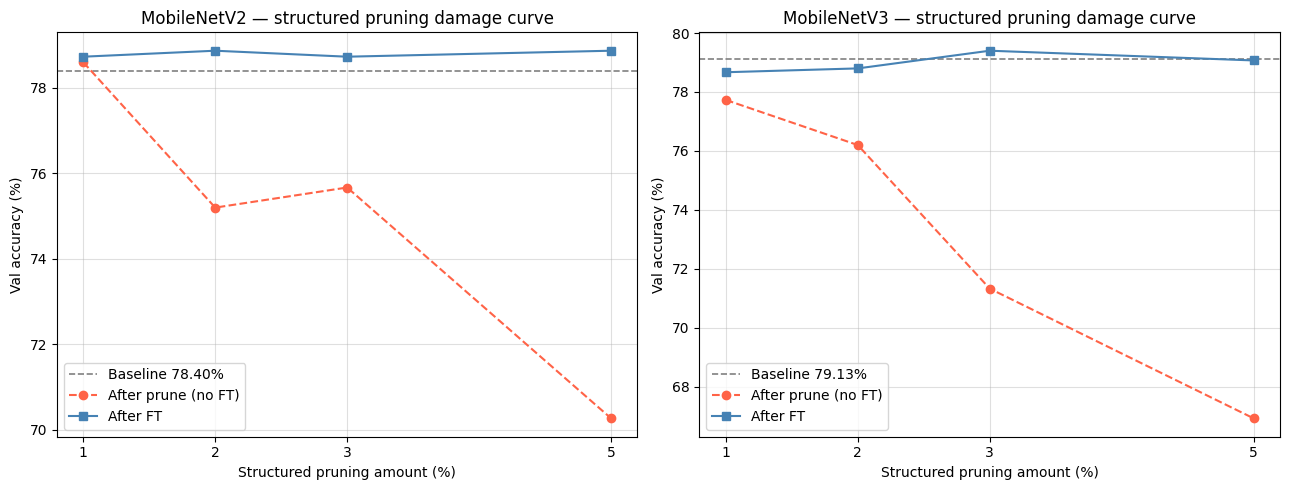

✅ Plot saved to Drive


In [27]:
# ── Damage curve — visualise accuracy vs sparsity ────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model_name in zip(axes, ACTIVE_MODELS):
    sub = df[df["model"] == model_name].sort_values("prune_%")
    if sub.empty:
        continue
    baseline = sub["baseline_%"].iloc[0]
    amounts  = sub["prune_%"].tolist()

    ax.axhline(baseline, color="gray", linestyle="--", linewidth=1.2, label=f"Baseline {baseline:.2f}%")
    ax.plot(amounts, sub["post_prune_%"].tolist(), "o--", color="tomato",   label="After prune (no FT)")
    ax.plot(amounts, sub["after_FT_%"].tolist(),   "s-",  color="steelblue", label="After FT")

    # NSE gate — shade failed runs
    for _, row in sub.iterrows():
        if not row["deploy"]:
            ax.axvspan(row["prune_%"] - 0.3, row["prune_%"] + 0.3, alpha=0.15, color="red")

    ax.set_title(f"{model_name} — structured pruning damage curve")
    ax.set_xlabel("Structured pruning amount (%)")
    ax.set_ylabel("Val accuracy (%)")
    ax.set_xticks(amounts)
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("/content/drive/My Drive/stm32-thesis/structured_probe_damage_curve.png", dpi=150)
plt.show()
print("✅ Plot saved to Drive")


## STM32N6 — next steps

Once you identify the best row from the results table above,
download its `int8_path` and run locally:

```
stedgeai.exe generate \
  --target stm32n6 \
  --name network \
  -m <int8_path> \
  --st-neural-art n6-allmems-O3@<X-CUBE-AI>/scripts/N6_scripts/user_neuralart.json \
  --workspace <tmp> --output <output_dir>
```

Check the `weights (ro)` line in the generate report.
Structured pruning at even 1–5% should produce a measurably smaller
weight block compared to the uncompressed baseline.
